In [145]:
import skimage as skim
import sklearn 
import cv2
import numpy as np

import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from skimage.color import rgb2hsv
from skimage.morphology import binary_dilation, disk

In [146]:
train_data_path = '../data/dataset_project_iapr2025/train/'
easy_path = train_data_path + 'L1000756.JPG'
hard_path = train_data_path + 'L1010032.JPG'

### Visualisation

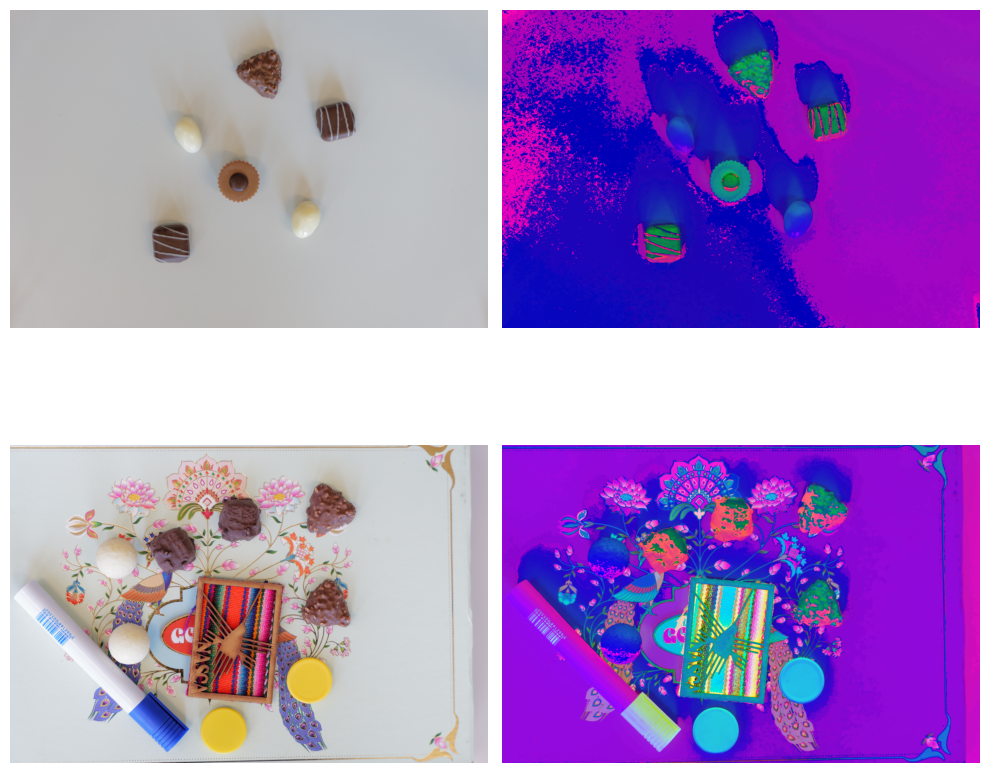

In [147]:


easy = np.array(Image.open(easy_path))
easy_hsv = skim.color.rgb2hsv(easy)

hard = np.array(Image.open(hard_path))
hard_hsv = skim.color.rgb2hsv(hard)

plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.imshow(easy)
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(easy_hsv)
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(hard)
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(hard_hsv)
plt.axis('off')

plt.tight_layout()

plt.show()


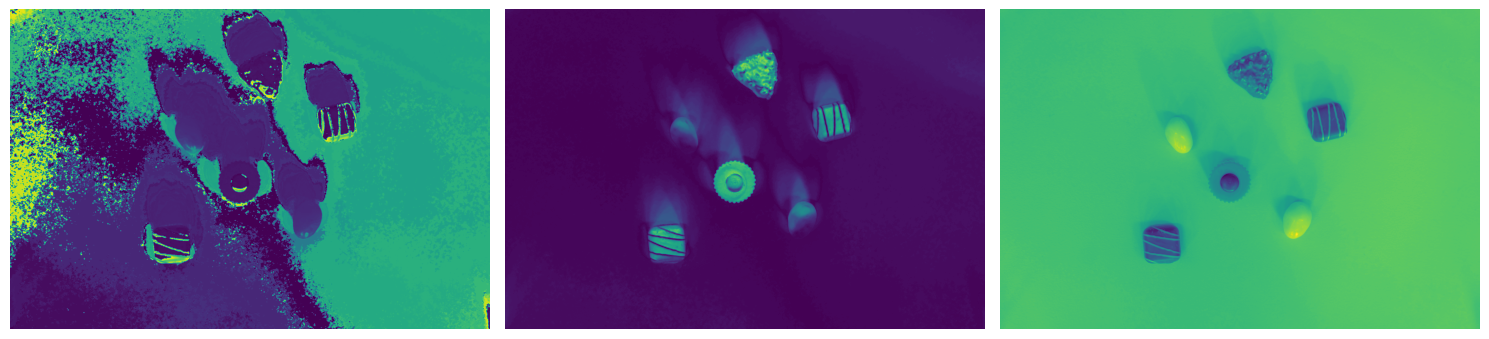

In [148]:

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(easy_hsv[:,:,0])
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(easy_hsv[:,:,1])
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(easy_hsv[:,:,2])
plt.axis('off')
plt.tight_layout()

plt.show()


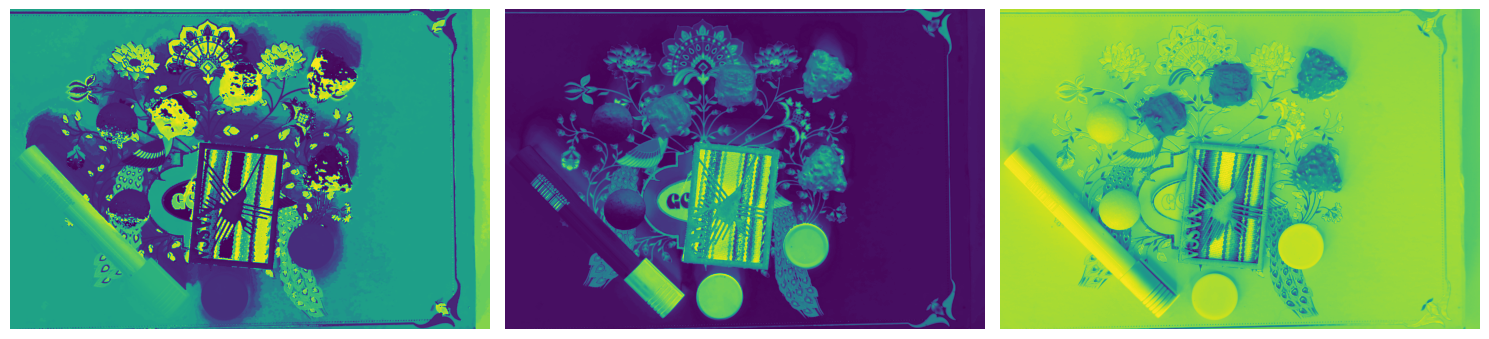

In [149]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(hard_hsv[:,:,0])
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(hard_hsv[:,:,1])
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(hard_hsv[:,:,2])
plt.axis('off')
plt.tight_layout()

plt.show()

**Histograms of HSV**

In [150]:
img = np.array(Image.open(hard_path))
img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

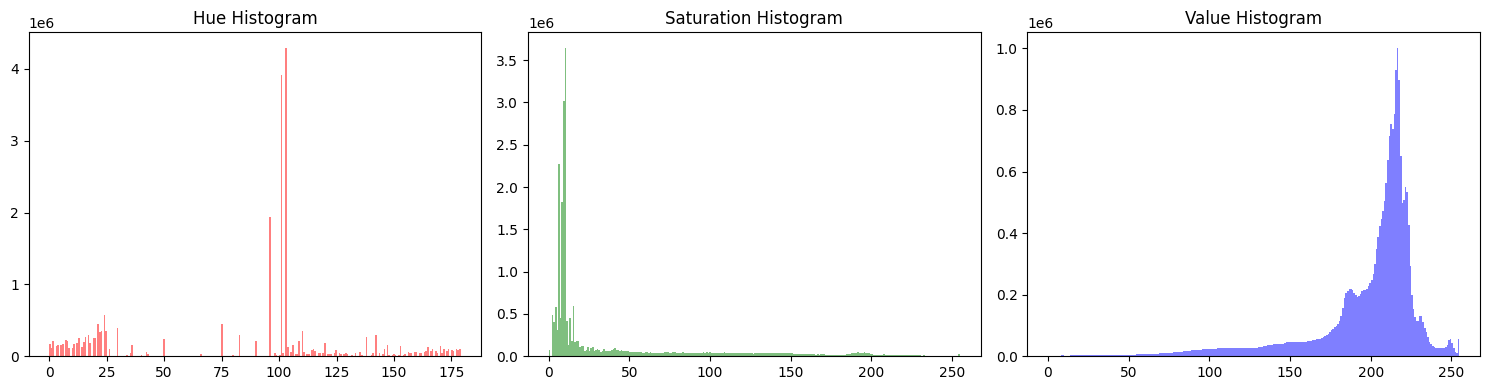

In [151]:
# visualize histograms
h = hsv[:,:,0]
s = hsv[:,:,1]
v = hsv[:,:,2]

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.hist(h.ravel(), bins=256, color='r', alpha=0.5) 
plt.title('Hue Histogram')
plt.subplot(1, 3, 2)
plt.hist(s.ravel(), bins=256, color='g', alpha=0.5)
plt.title('Saturation Histogram')
plt.subplot(1, 3, 3)
plt.hist(v.ravel(), bins=256, color='b', alpha=0.5)
plt.title('Value Histogram')
plt.tight_layout()
plt.show()

**Histograms after sampling**

24000000


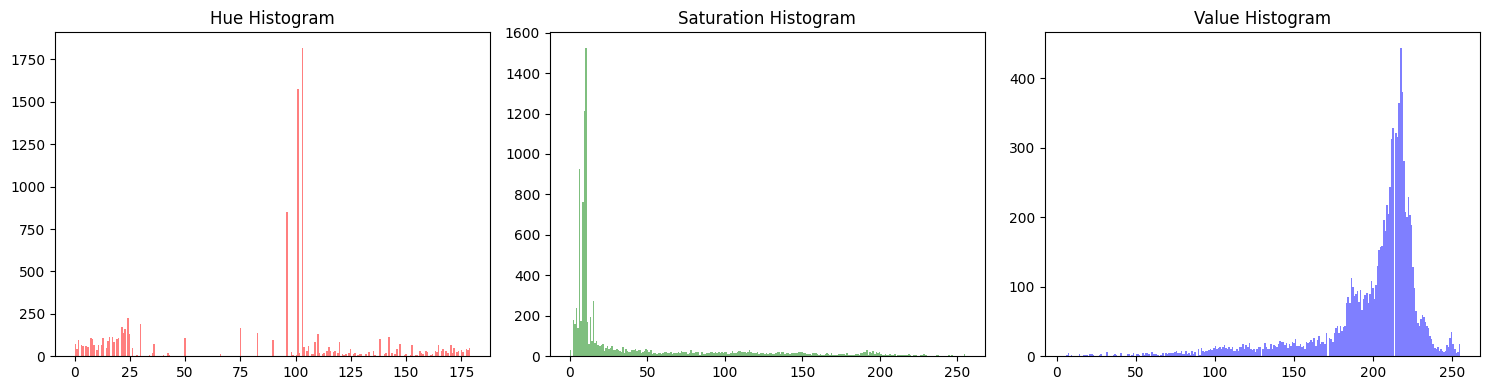

In [152]:
print(len(h.ravel()))

h = np.random.choice(h.ravel(), 10000)
s = np.random.choice(s.ravel(), 10000)
v = np.random.choice(v.ravel(), 10000)

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.hist(h, bins=256, color='r', alpha=0.5)
plt.title('Hue Histogram')
plt.subplot(1, 3, 2)
plt.hist(s, bins=256, color='g', alpha=0.5)
plt.title('Saturation Histogram')
plt.subplot(1, 3, 3)
plt.hist(v, bins=256, color='b', alpha=0.5)
plt.title('Value Histogram')
plt.tight_layout()
plt.show()



### GMM for segmentation
**Preprocessing: binning and bluring**

In [153]:
### median binning

def median_bin_rgb(image, block_size=(2, 2)):
    channels = []
    for i in range(3):  # R, G, B
        channel = skim.measure.block_reduce(image[:, :, i], block_size=block_size, func=np.median)
        channels.append(channel)
    return np.stack(channels, axis=-1).astype(np.uint8)


(400, 600, 3)


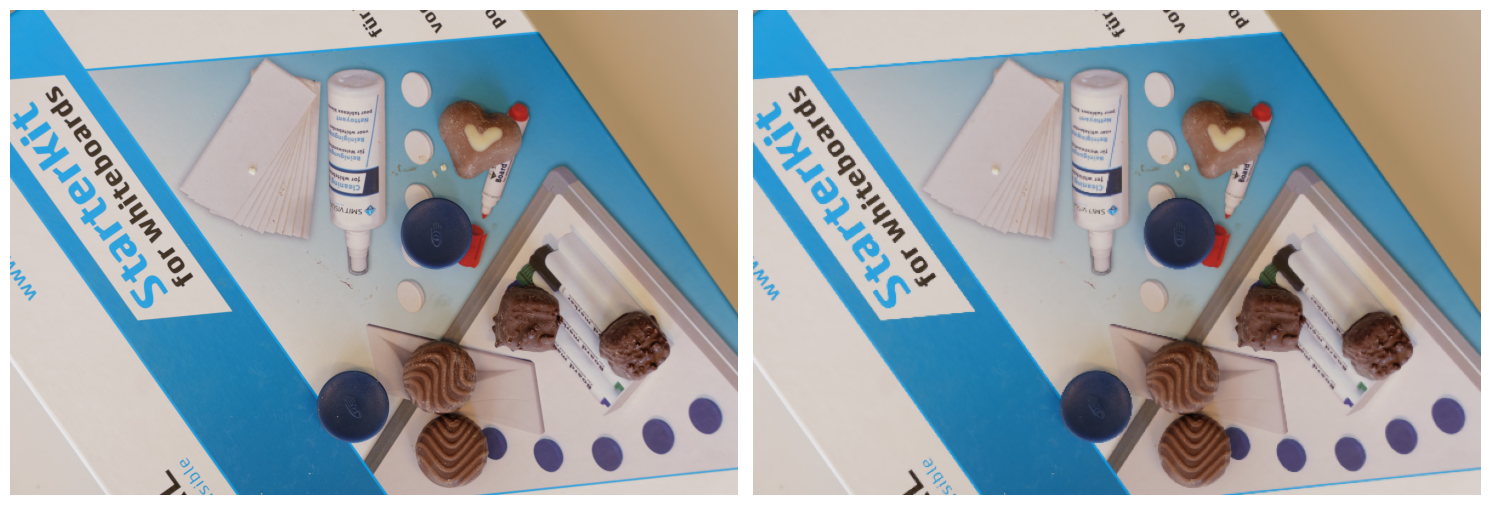

In [154]:
img = np.array(Image.open(train_data_path + 'L1000993.JPG'))
binned = median_bin_rgb(img, block_size=(10, 10))
binned = skim.filters.gaussian(binned, sigma=.4, channel_axis=2, preserve_range=True).astype(np.uint8)
print(binned.shape)

plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(binned)
plt.axis('off')
plt.tight_layout()
plt.show()

In [155]:
img_bgr = cv2.cvtColor(binned, cv2.COLOR_RGB2BGR)
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
#hsv = binned.copy()
#hsv = hsv[:,:, 1:3]
hsv = hsv.reshape(-1, 3)

empirical_mask = (hsv[:,0]>0) & (hsv[:,0]<100) & (hsv[:,1]>50) & (hsv[:,1]<200) & (hsv[:,2]>50) & (hsv[:,2]<180)


low_sat_mask = hsv[:, 1] < 0.2*255 #hue is very noisy when sat is low
hsv[low_sat_mask, 0] = 0


hsv_masked = hsv[empirical_mask]
components = range(1, 10)

sample_idx = np.random.choice(hsv_masked.shape[0], 10000, replace=False)
hsv_sample = hsv_masked[sample_idx, :]



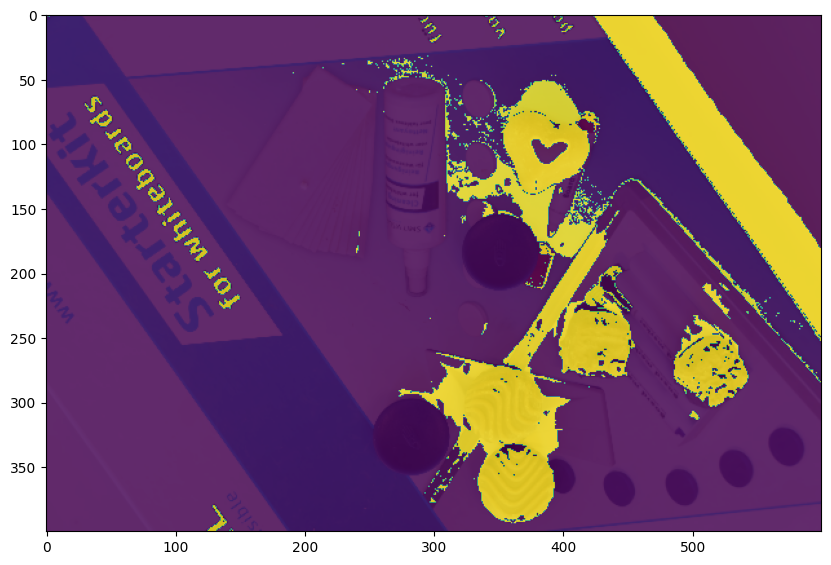

In [156]:
plt.figure(figsize=(10, 10))
plt.imshow(binned)
plt.imshow(empirical_mask.reshape(binned.shape[:2]), alpha=0.8)
plt.show()

100%|██████████| 9/9 [00:02<00:00,  3.80it/s]


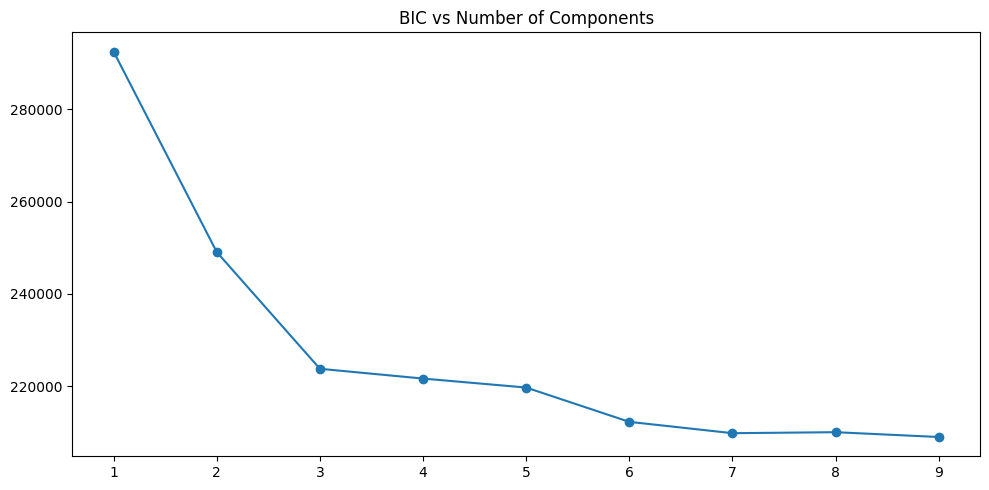

In [157]:
best_bic = np.inf
best_gmm = None
best_n_components = 0
bics = []

for c in tqdm(components):
    gmm = sklearn.mixture.GaussianMixture(n_components=c, covariance_type='full', reg_covar=1e-3)
    gmm.fit(hsv_sample)
    bic = gmm.bic(hsv_sample)
    bics.append(bic)
    if bic < best_bic:
        best_bic = bic
        best_gmm = gmm
        best_n_components = c

plt.figure(figsize=(10, 5))
plt.plot(components, bics, marker='o')
plt.title('BIC vs Number of Components')
plt.tight_layout()
plt.show()  


0 8


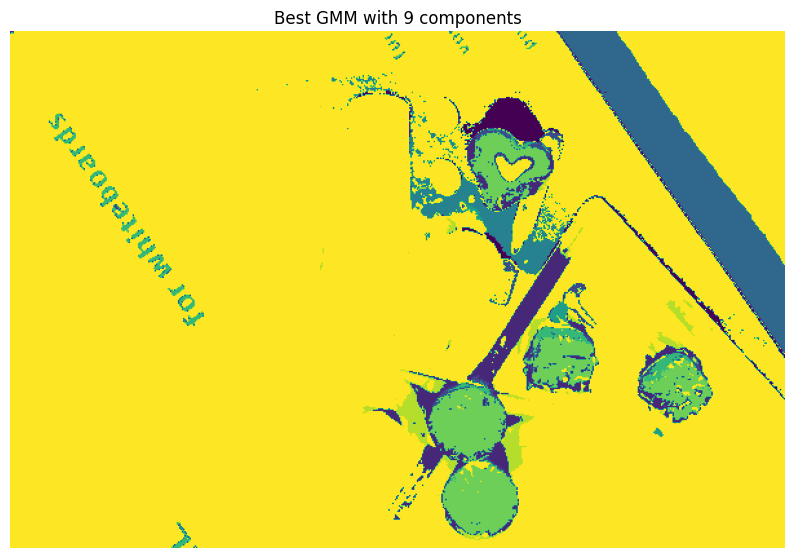

In [158]:
labels = best_gmm.predict(hsv)
print(np.min(labels), np.max(labels))
labels[~empirical_mask] = np.max(labels)+1
labels = labels.reshape(binned.shape[0], binned.shape[1])
plt.figure(figsize=(10, 10))
plt.imshow(labels)
plt.axis('off')
plt.title(f'Best GMM with {best_n_components} components')
plt.show()

In [159]:
print(best_gmm.means_)

[[ 97.39718502 124.12316253 126.3043139 ]
 [  9.43669649  76.8597587  129.92851007]
 [  8.51635957 122.00778913  92.06114413]
 [ 16.63908427 104.40645834 171.13452906]
 [ 97.69402047  77.32401073 158.34038163]
 [ 57.09277349  80.34158979  90.33314598]
 [ 12.25802113 117.13654532  65.67405782]
 [  8.22172895 138.65295749 105.93797713]
 [  8.71409735  56.32319984 163.39469838]]


[190 160 114]


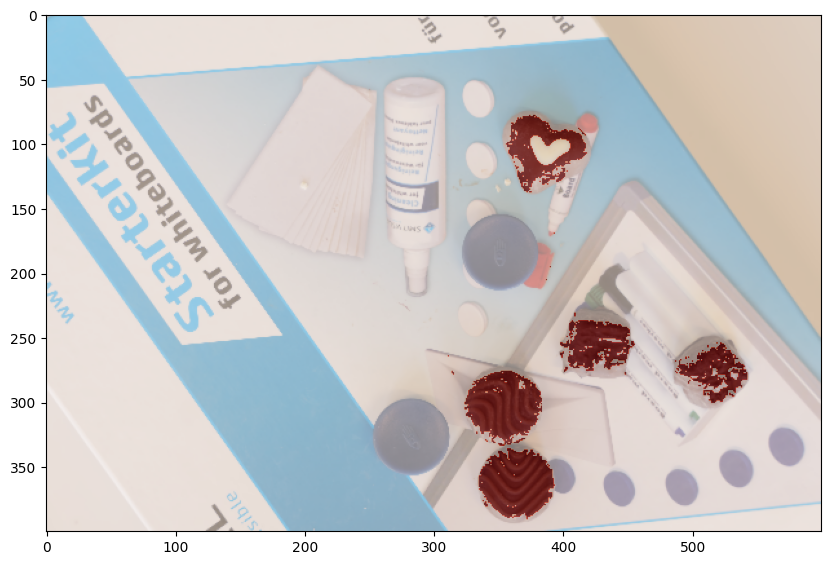

In [160]:
benchmark = [10, 125, 115]

distances = np.linalg.norm(best_gmm.means_ - benchmark, axis=1)
idx = np.argmin(distances)

binary = labels == idx
plt.figure(figsize=(10, 10))
plt.imshow(binned)
plt.imshow(binary, alpha=0.5, cmap='Reds')
#plt.axis('off')
print(binned[100,380])


### RGB & HSV Plot

In [161]:
from typing import Callable # DANGER, not in the requirement.txt

# Plot color space distribution 
def plot_colors_histo(
    img: np.ndarray,
    func: Callable,
    labels: list[str],
):
    """
    Plot the original image (top) as well as the channel's color distributions (bottom).

    Args
    ----
    img: np.ndarray (M, N, C)
        Input image of shape MxN and C channels.
    func: Callable
        A callable function that extracts D channels from the input image
    labels: list of str
        List of D labels indicating the name of the channel
    """

    # Extract colors
    channels = func(img=img)
    C2 = len(channels)
    M, N, C1 = img.shape
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, C2)

    # Use random seed to downsample image colors (increase run speed - 10%)
    mask = np.random.RandomState(seed=0).rand(M, N) < 0.1
    
    # Plot base image
    ax = fig.add_subplot(gs[:2, :])
    ax.imshow(img)
    # Remove axis
    ax.axis('off')
    ax1 = fig.add_subplot(gs[2, 0])
    ax2 = fig.add_subplot(gs[2, 1])
    ax3 = fig.add_subplot(gs[2, 2])

    # Plot channel distributions
    ax1.scatter(channels[0][mask].flatten(), channels[1][mask].flatten(), c=img[mask]/255, s=1, alpha=0.1)
    ax1.set_xlabel(labels[0])
    ax1.set_ylabel(labels[1])
    ax1.set_title("{} vs {}".format(labels[0], labels[1]))
    ax2.scatter(channels[0][mask].flatten(), channels[2][mask].flatten(), c=img[mask]/255, s=1, alpha=0.1)
    ax2.set_xlabel(labels[0])
    ax2.set_ylabel(labels[2])
    ax2.set_title("{} vs {}".format(labels[0], labels[2]))
    ax3.scatter(channels[1][mask].flatten(), channels[2][mask].flatten(), c=img[mask]/255, s=1, alpha=0.1)
    ax3.set_xlabel(labels[1])
    ax3.set_ylabel(labels[2])
    ax3.set_title("{} vs {}".format(labels[1], labels[2]))
        
    plt.tight_layout()

In [162]:
def extract_hsv_channels(img):
    M, N, C = np.shape(img)

    data_h = np.zeros((M, N))
    data_s = np.zeros((M, N))
    data_v = np.zeros((M, N))

    hsv_img = rgb2hsv(img)

    data_h = hsv_img[:,:,0]
    data_s = hsv_img[:,:,1]
    data_v = hsv_img[:,:,2]

    return data_h, data_s, data_v

def extract_rgb_channels(img):
    M, N, C = np.shape(img)

    data_r = np.zeros((M, N))
    data_g = np.zeros((M, N))
    data_b = np.zeros((M, N))

    data_r = img[:,:,0]
    data_g = img[:,:,1]
    data_b = img[:,:,2]

    return data_r, data_g, data_b

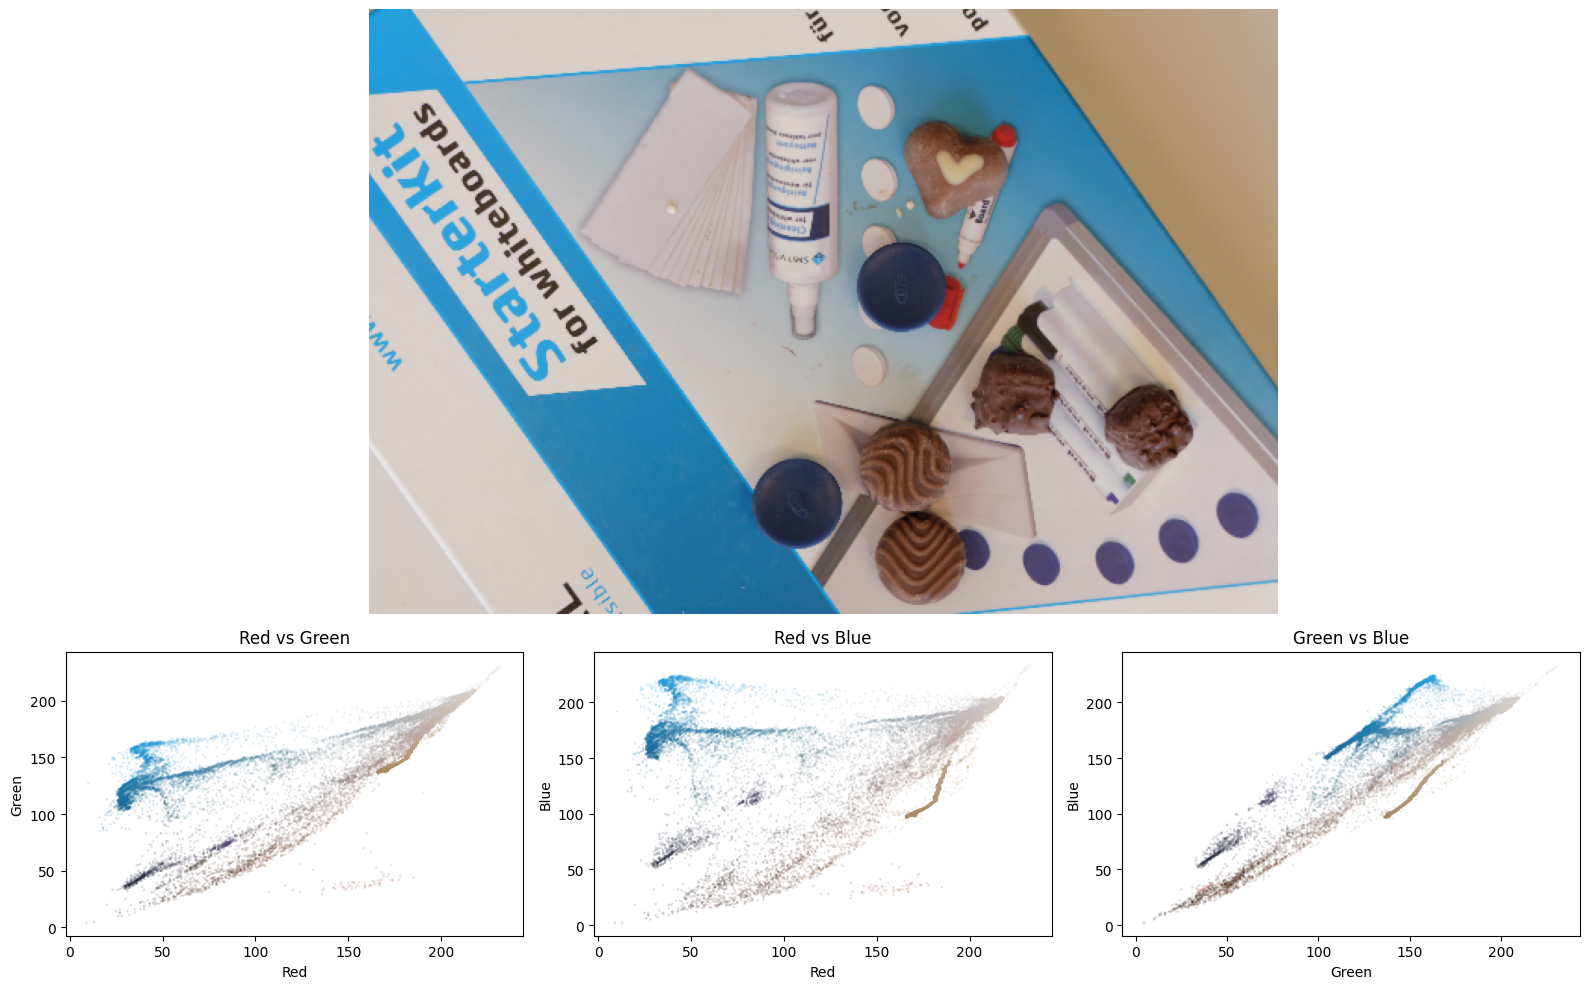

In [163]:
plot_colors_histo(
    img = binned,
    func = extract_rgb_channels,
    labels = ["Red", "Green", "Blue"],
)

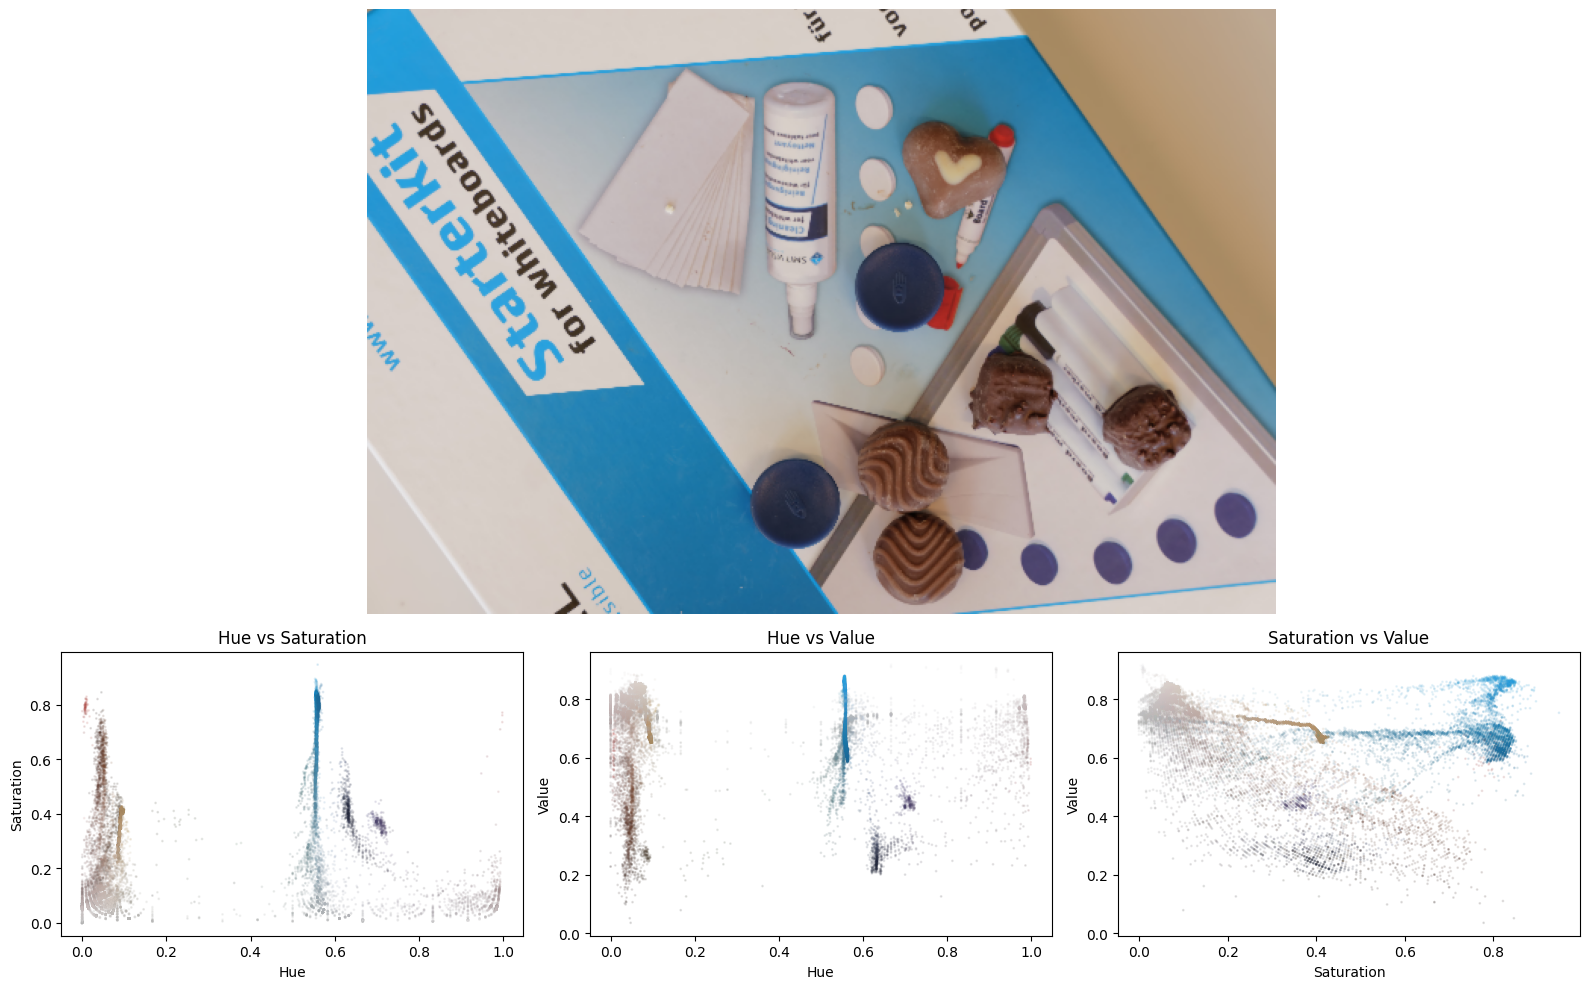

In [164]:
plot_colors_histo(
    img = binned,
    func = extract_hsv_channels,
    labels = ["Hue", "Saturation", "Value"],
)

### Region Growing

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

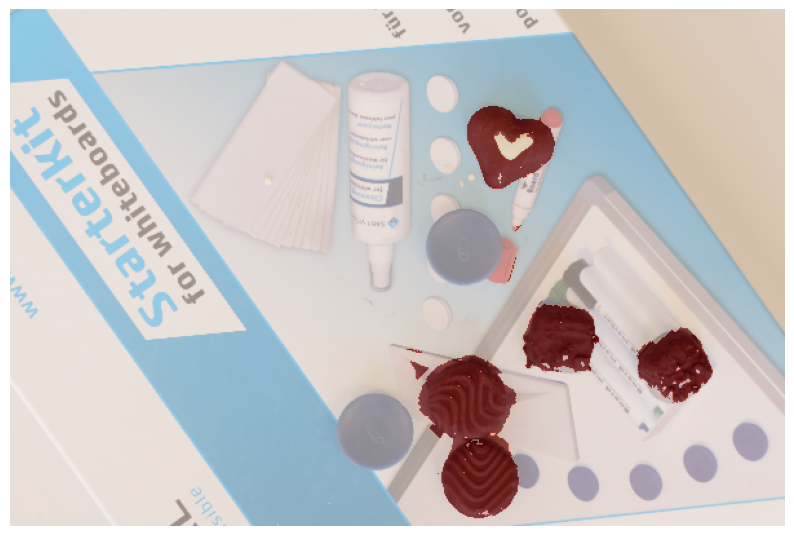

In [185]:
hsv_img = rgb2hsv(binned)
n_iterations = 3
threshold_rgb = [0, 0, 0]
threshold_hsv = [0.2, 0, 0]

M, N = np.shape(binary)
rg = binary.copy()
rg = binary_dilation(rg, disk(2))

binned_labelled = ((binned[:,:,1] < binned[:,:,0]) & (binned[:,:,2] < binned[:,:,0]) & (binned[:,:,2] < 10 - binned[:,:,1]) &
                   (hsv_img[:,:,0] < threshold_hsv[0]) & (hsv_img[:,:,1] < 0.9) & (hsv_img[:,:,2] < 1.1 - hsv_img[:,:,1]))

for i in range(n_iterations):         
    rg = binary_dilation(rg, disk(2)) & binned_labelled         

plt.figure(figsize=(10, 10))
plt.imshow(binned)
plt.imshow(rg, alpha=0.5, cmap='Reds')
plt.axis('off')


### Binary image processing


In [166]:
processed = skim.morphology.remove_small_holes(binary, area_threshold=200)
processed = skim.morphology.remove_small_objects(processed, min_size=50)
#processed = skim.morphology.binary_closing(processed, skim.morphology.disk(9))

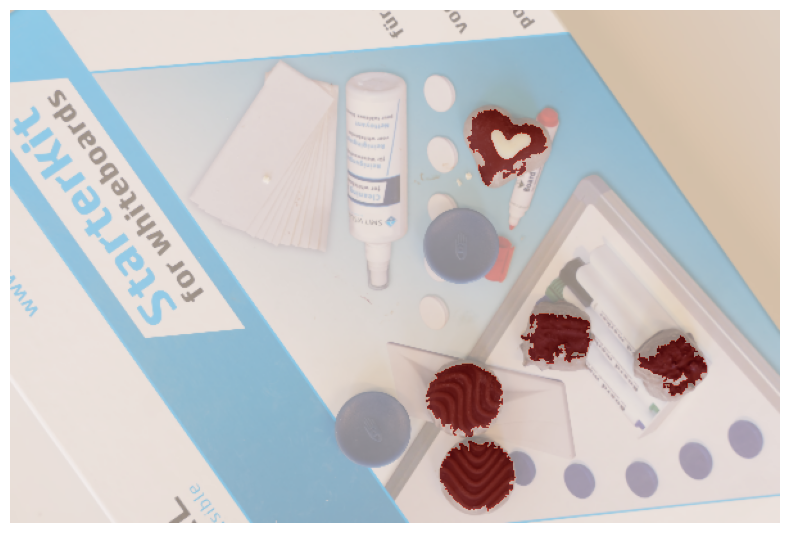

In [167]:
plt.figure(figsize=(8, 8))
plt.imshow(binned)
plt.imshow(processed, alpha=0.5, cmap='Reds')
plt.axis('off')
plt.tight_layout()
plt.show()